In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.1 MB/s eta 0:00:00


In [2]:
import os
import random
from pathlib import Path
from collections import Counter
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
classes = [
    "Longitudinal Crack",
    "Transverse Crack",
    "Alligator Crack",
    "Other Corruption",
    "Pothole"
]

print(classes)

['Longitudinal Crack', 'Transverse Crack', 'Alligator Crack', 'Other Corruption', 'Pothole']


In [7]:
# 1. Dataset Overview
dataset_path = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")
class_names = ["Longitudinal Crack", "Transverse Crack", "Alligator Crack", "Other Corruption", "Pothole"]

splits = ["train", "val", "test"]
overview_data = []

for split in splits:
    img_dir = dataset_path / split / "images"
    lbl_dir = dataset_path / split / "labels"
    
    num_images = len(list(img_dir.glob("*.*"))) if img_dir.exists() else 0
    num_labels = len(list(lbl_dir.glob("*.*"))) if lbl_dir.exists() else 0
    
    overview_data.append({
        "Split": split,
        "Images Count": num_images,
        "Labels Count": num_labels
    })

df_overview = pd.DataFrame(overview_data)
display(df_overview)

,Split,Images Count,Labels Count
0,train,26869,26869
1,val,5758,5758
2,test,5758,5758


In [9]:
from tqdm import tqdm

TRAIN_LABELS = dataset_path / "train" / "labels"

class_counts = {i: 0 for i in range(len(class_names))}

label_files = list(TRAIN_LABELS.glob("*.txt"))

for label_file in tqdm(label_files):
    with open(label_file, "r") as file:
        lines = file.readlines()
        for line in lines:
            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

num_obj = np.sum(list(class_counts.values()))

class_df_train = pd.DataFrame({
    "Class": class_names,
    "Objects": list(class_counts.values()),
    "percentage": list(class_counts.values()) / num_obj * 100
})

display(class_df_train)

100%|██████████| 26869/26869 [00:25<00:00, 1057.71it/s]


,Class,Objects,percentage
0,Longitudinal Crack,18201,39.314412
1,Transverse Crack,8386,18.113876
2,Alligator Crack,7527,16.258424
3,Other Corruption,7554,16.316744
4,Pothole,4628,9.996544


/tmp/ipykernel_49/105789180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_df_train, x="Class", y="Objects", palette="viridis")


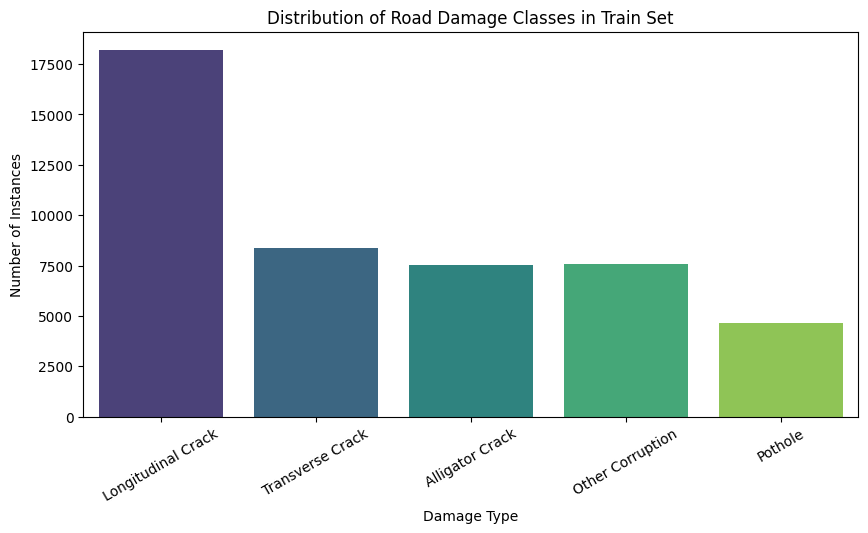

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=class_df_train, x="Class", y="Objects", palette="viridis")
plt.xticks(rotation=30)
plt.title("Distribution of Road Damage Classes in Train Set")
plt.xlabel("Damage Type")
plt.ylabel("Number of Instances")
plt.show()

In [11]:
yaml_content = f"""
path: {dataset_path.resolve()}
train: train/images
val: val/images
test: test/images

nc: {len(class_names)}
names: {class_names}
"""

yaml_path = Path("/kaggle/working/data.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(f"data.yaml successfully created at: {yaml_path}")

data.yaml successfully created at: /kaggle/working/data.yaml


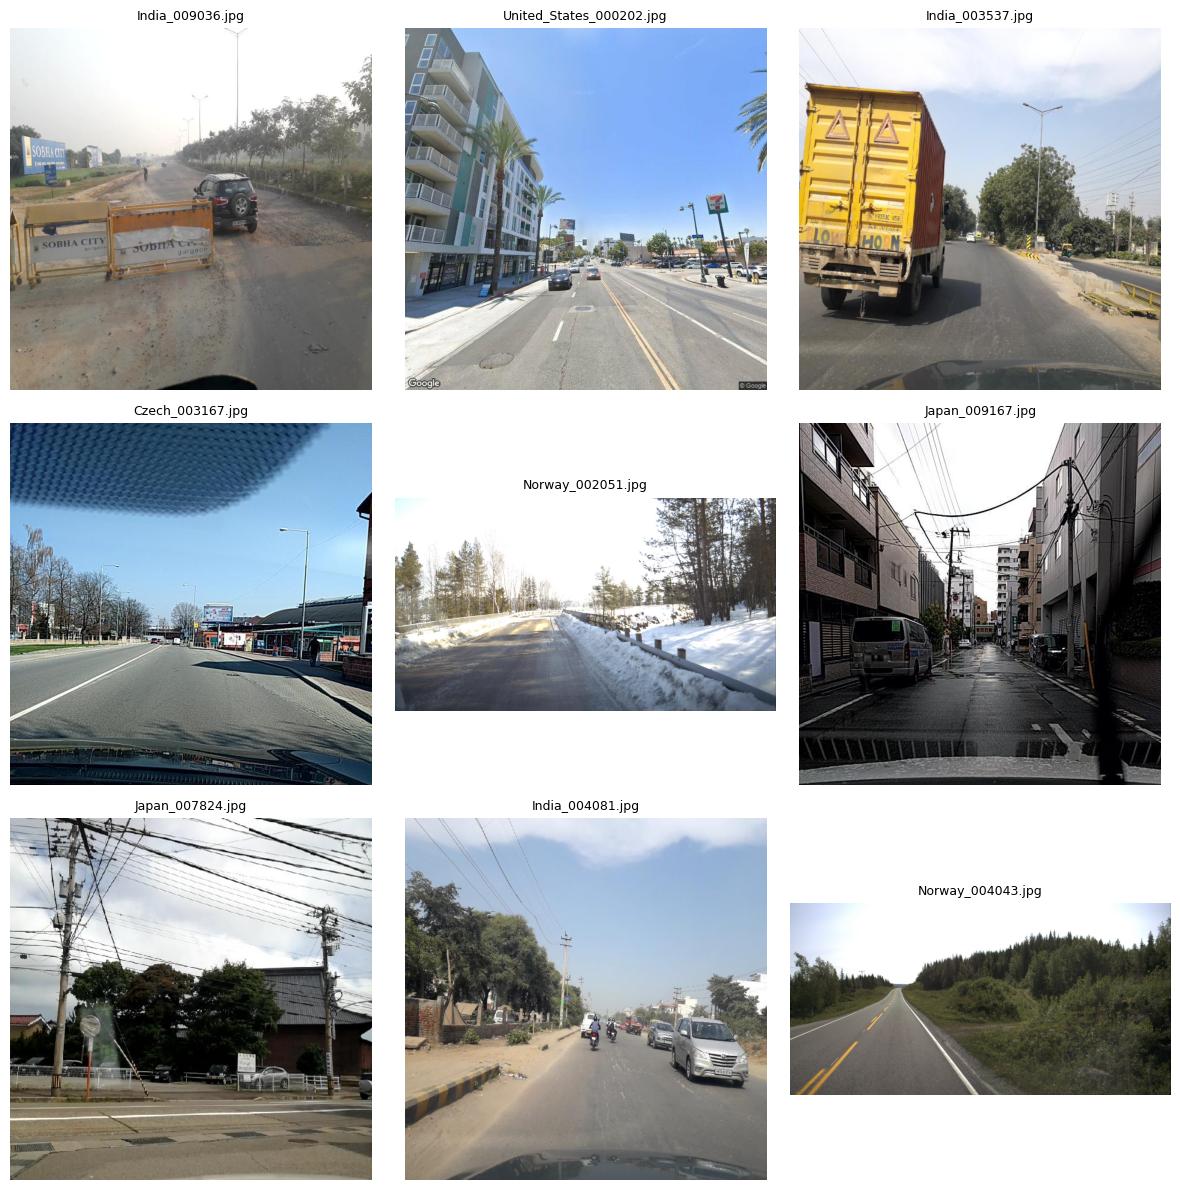

In [12]:
TRAIN_IMAGES = dataset_path / "train" / "images"

image_files = os.listdir(TRAIN_IMAGES)
random_images = random.sample(image_files, 9)

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(random_images):
    image_path = os.path.join(TRAIN_IMAGES, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(image_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
import warnings
warnings.filterwarnings("ignore")
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    name="road_damage_yolo11"
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_damage_yolo11, nbs=64, nms=None, opset=None, optimize=Fals

In [14]:
import shutil
from pathlib import Path

source_weights_dir = Path("/kaggle/working/runs/detect/road_damage_yolo11/weights")

if source_weights_dir.exists():
    print("Training finished successfully! Best and Last weights are saved.")
    
    best_model_path = source_weights_dir / "best.pt"
    last_model_path = source_weights_dir / "last.pt"
    
    print(f"Best Model: {best_model_path}")
    print(f"Last Model: {last_model_path}")
else:
    print("Training is still running or the path was not found.")

Training finished successfully! Best and Last weights are saved.
Best Model: /kaggle/working/runs/detect/road_damage_yolo11/weights/best.pt
Last Model: /kaggle/working/runs/detect/road_damage_yolo11/weights/last.pt


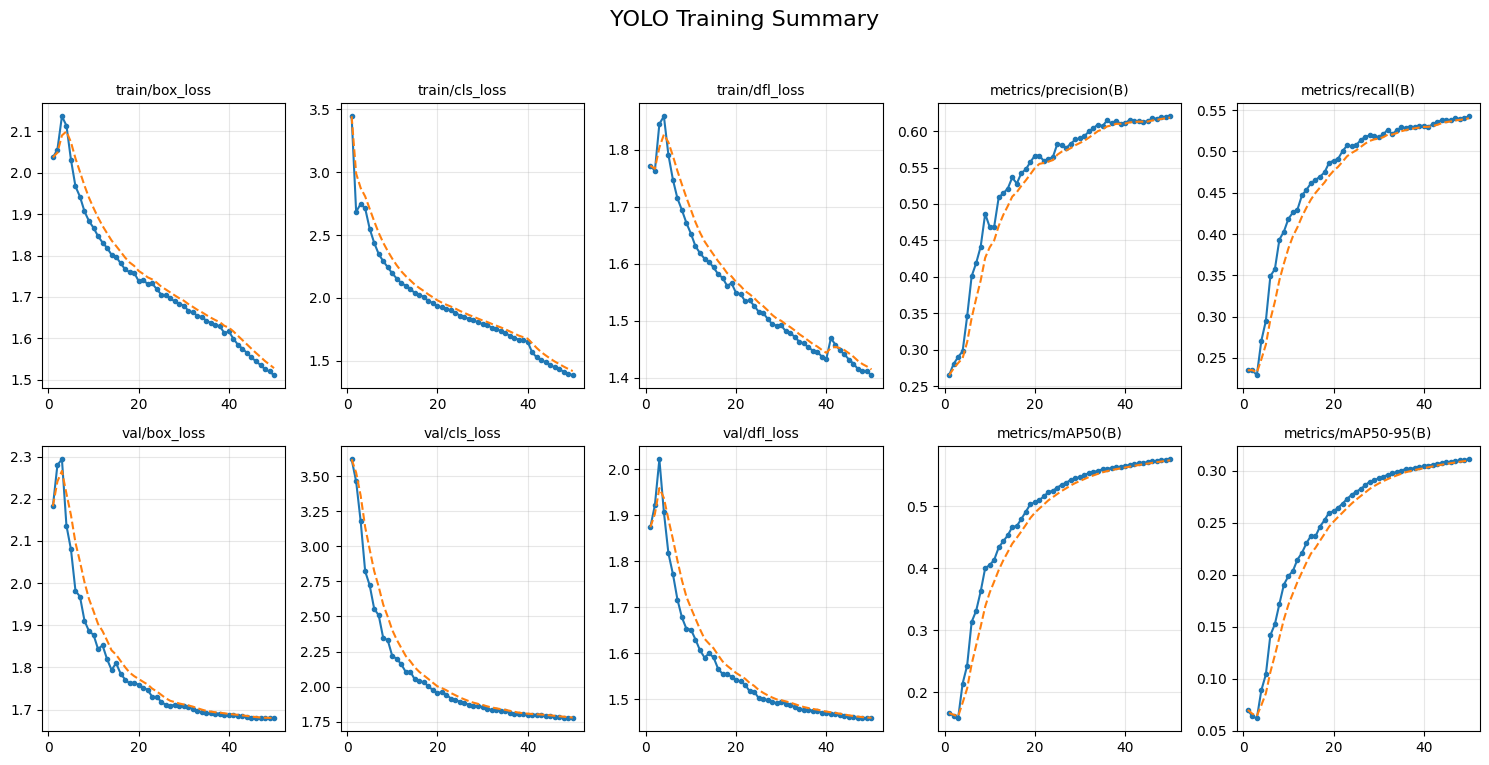

In [15]:
results_path = Path("/kaggle/working/runs/detect/road_damage_yolo11/results.csv")

if results_path.exists():
    df_results = pd.read_csv(results_path)
    df_results.columns = [col.strip() for col in df_results.columns]
    
    metrics_cols = [
        'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
        'metrics/precision(B)', 'metrics/recall(B)',
        'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
        'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
    ]
    
    epochs = df_results['epoch']
    
    plt.figure(figsize=(15, 8))
    plt.suptitle("YOLO Training Summary", fontsize=16)
    
    for i, col in enumerate(metrics_cols):
        if col in df_results.columns:
            plt.subplot(2, 5, i + 1)
            plt.plot(epochs, df_results[col], marker='o', markersize=3, label='results')
            plt.plot(epochs, df_results[col].ewm(span=5).mean(), linestyle='--', label='smooth')
            plt.title(col, fontsize=10)
            plt.grid(True, alpha=0.3)
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Results file not found!")

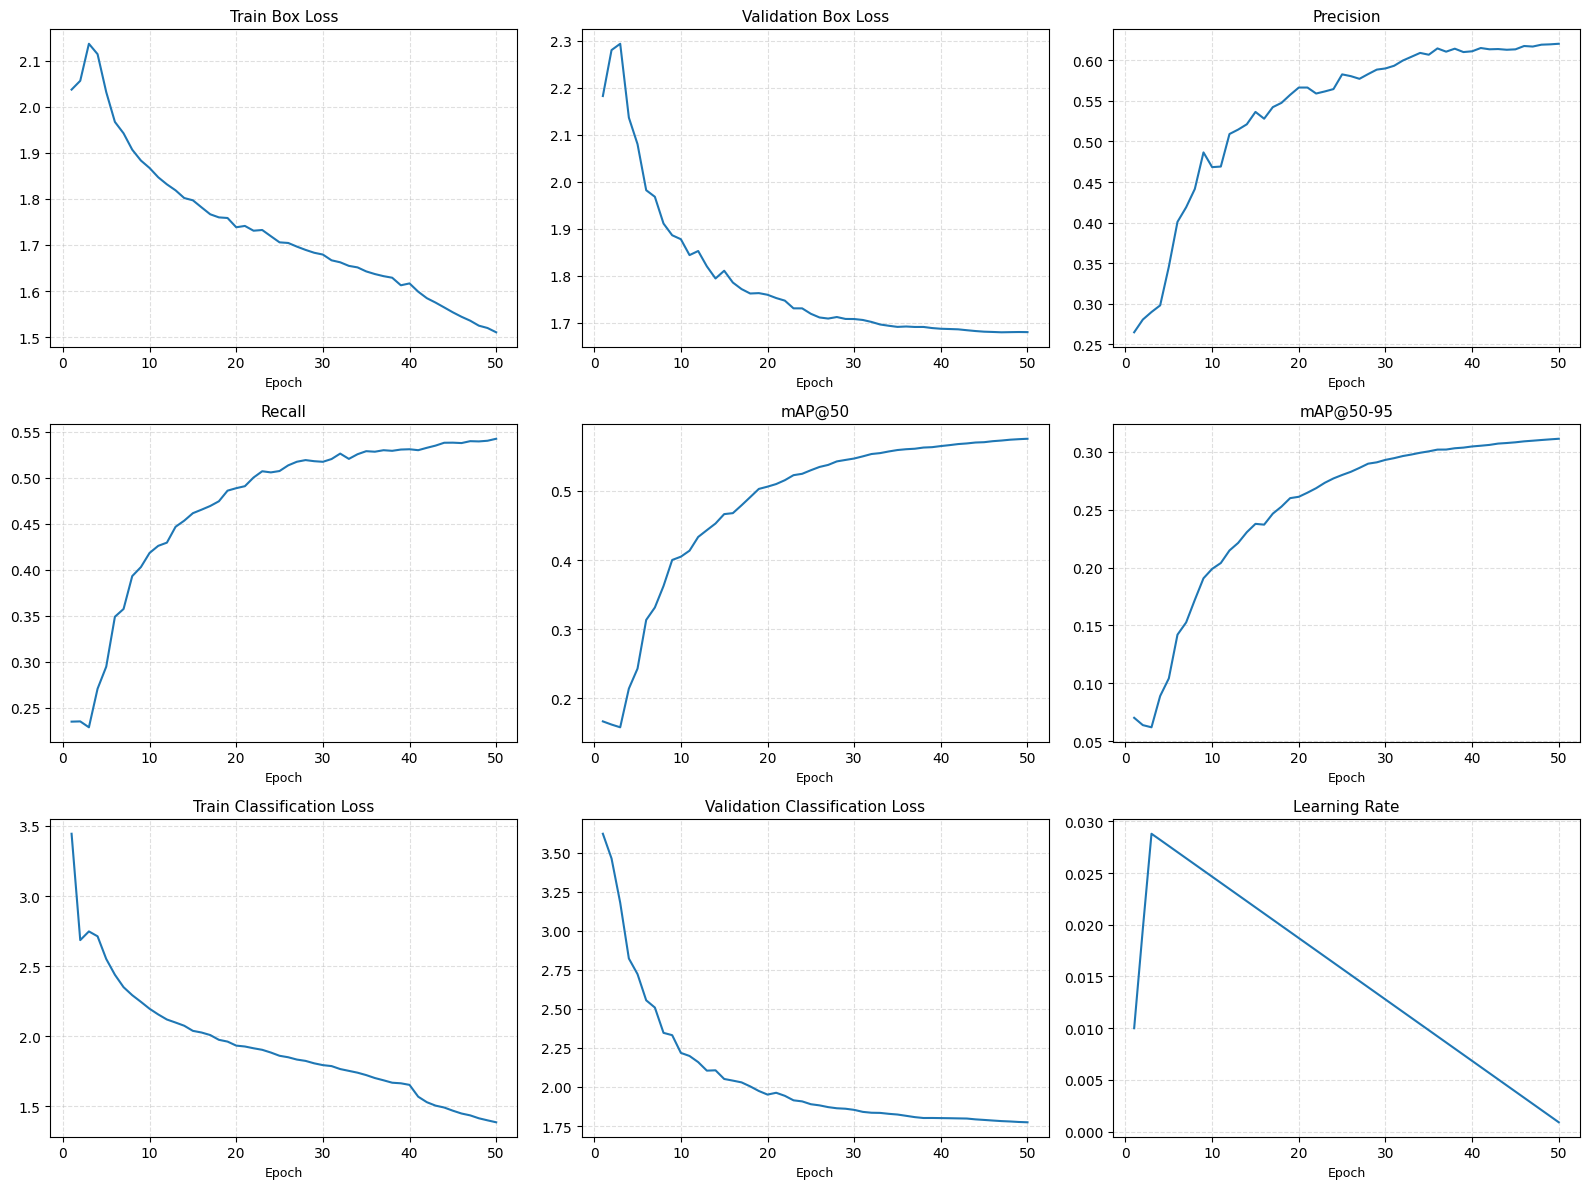

In [16]:
results_path = Path("/kaggle/working/runs/detect/road_damage_yolo11/results.csv")

if results_path.exists():
    df = pd.read_csv(results_path)
    df.columns = [col.strip() for col in df.columns]
    
    columns_to_plot = [
        ('train/box_loss', 'Train Box Loss'),
        ('val/box_loss', 'Validation Box Loss'),
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)', 'Recall'),
        ('metrics/mAP50(B)', 'mAP@50'),
        ('metrics/mAP50-95(B)', 'mAP@50-95'),
        ('train/cls_loss', 'Train Classification Loss'),
        ('val/cls_loss', 'Validation Classification Loss'),
        ('lr/pg0', 'Learning Rate')
    ]
    
    epochs = df['epoch']
    
    plt.figure(figsize=(16, 12))
    
    for i, (col, title) in enumerate(columns_to_plot):
        if col in df.columns:
            plt.subplot(3, 3, i + 1)
            plt.plot(epochs, df[col], color='#1f77b4', linewidth=1.5)
            plt.title(title, fontsize=11)
            plt.xlabel('Epoch', fontsize=9)
            plt.grid(True, linestyle='--', alpha=0.4)
            
    plt.tight_layout()
    plt.show()
else:
    print("Results file not found!")

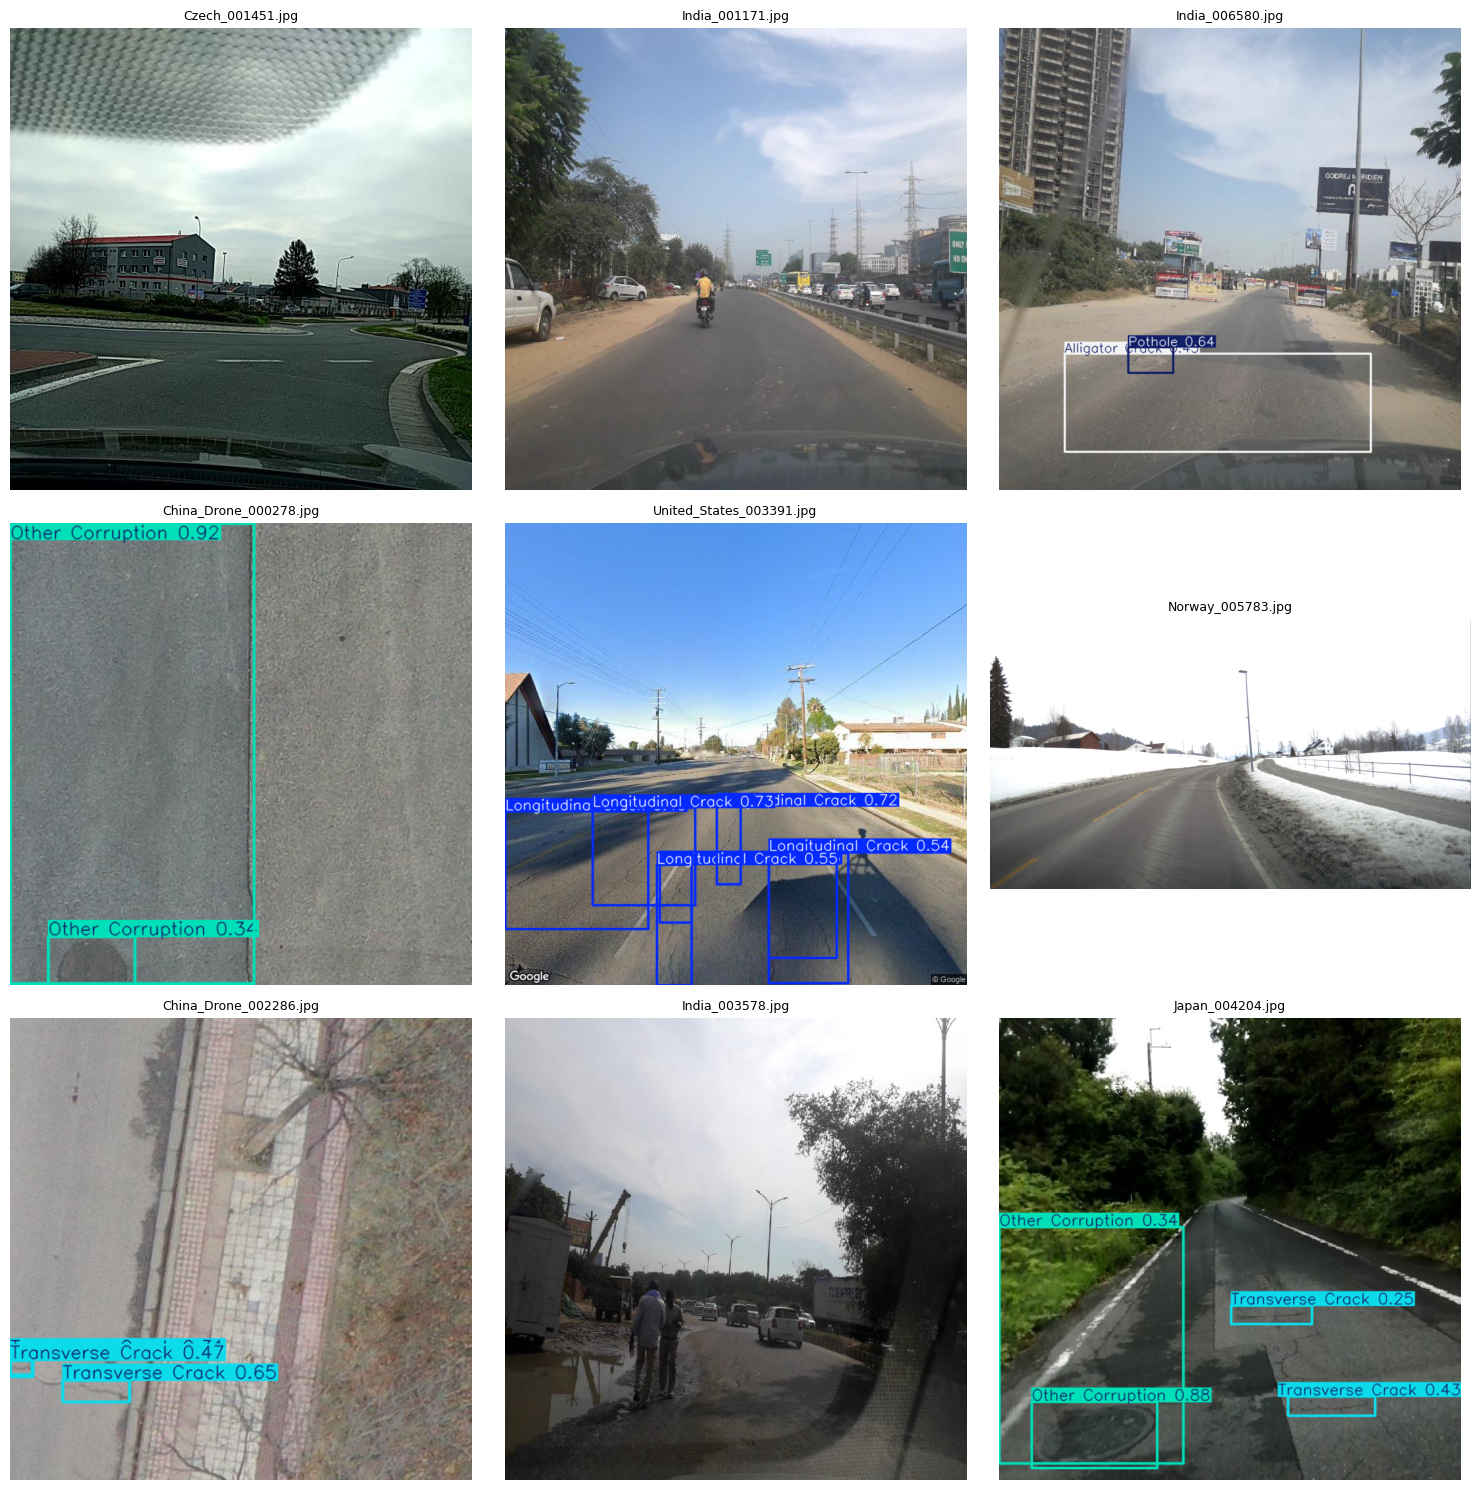

In [18]:
model_path = Path("/kaggle/working/runs/detect/road_damage_yolo11/weights/best.pt")
trained_model = YOLO(model_path)

test_images_dir = dataset_path / "test" / "images"
test_image_files = list(test_images_dir.glob("*.*"))

selected_test_images = random.sample(test_image_files, min(9, len(test_image_files)))

plt.figure(figsize=(15, 15))

for i, img_path in enumerate(selected_test_images):
    results = trained_model(str(img_path), conf=0.25, verbose=False)
    
    res_plotted = results[0].plot()
    res_plotted_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(res_plotted_rgb)
    plt.title(img_path.name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
model_path = Path("/kaggle/working/runs/detect/road_damage_yolo11/weights/best.pt")
model = YOLO(model_path)

metrics = model.val(data=str(yaml_path), split='val')

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 164.3±325.9 MB/s, size: 288.6 KB)
val: Scanning /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels... 5758 images, 1837 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 420.6it/s 13.7s0.1s
val: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Japan_006536.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 5.4it/s 1:070.1sss
                   all       5758       9740      0.621      0.543      0.576      0.311
    Longitudinal Crack       2011       3890      0.598      0.507      0.535      0.297
      Transverse Cr

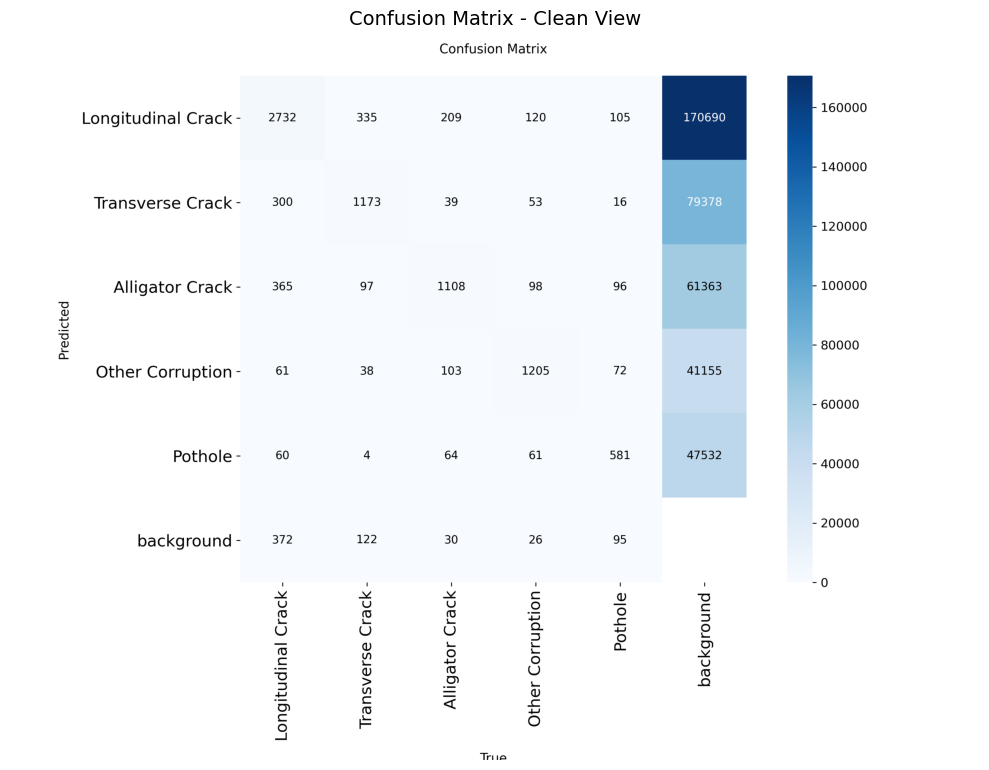

In [21]:
val_dir = Path("/kaggle/working/runs/detect/val")
confusion_mat_path = val_dir / "confusion_matrix.png"

if confusion_mat_path.exists():
    img_cm = cv2.imread(str(confusion_mat_path))
    img_cm_rgb = cv2.cvtColor(img_cm, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img_cm_rgb)
    plt.title("Confusion Matrix - Clean View", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrix image not found!")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 174.1±198.1 MB/s, size: 989.7 KB)
val: Scanning /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels... 5758 images, 1837 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 717.7it/s 8.0s0.1s
val: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Japan_006536.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 5.5it/s 1:060.1sss
                   all       5758       9740      0.621      0.543      0.576      0.311
    Longitudinal Crack       2011       3890      0.598      0.507      0.535      0.297
      Transverse Cra

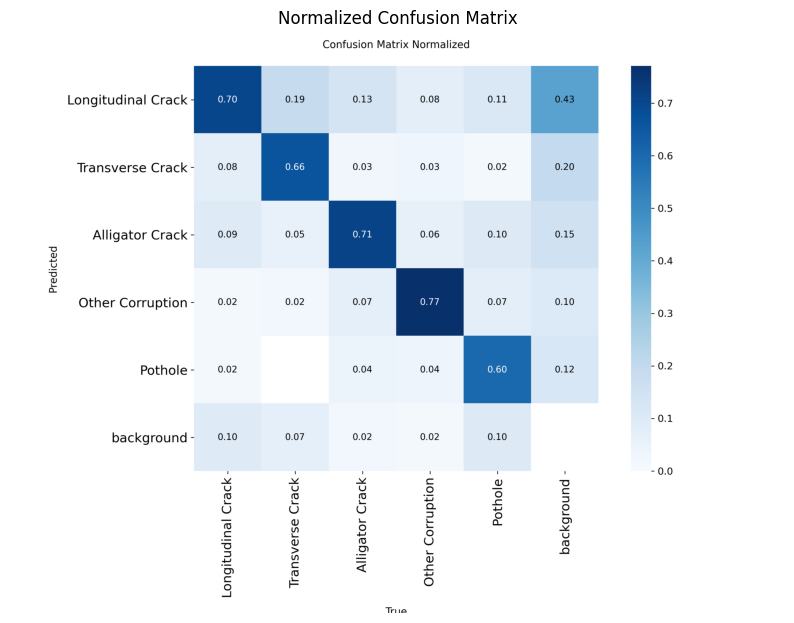

In [22]:
metrics = model.val(data=str(yaml_path), split='val', plots=True)

val_dir = Path("/kaggle/working/runs/detect/val")
cm_norm_path = val_dir / "confusion_matrix_normalized.png"

if cm_norm_path.exists():
    img = cv2.imread(str(cm_norm_path))
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Normalized Confusion Matrix", fontsize=12)
    plt.axis("off")
    plt.show()